In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.array as da

import ipywidgets as widgets
from IPython.display import display, clear_output

import torch
import torch.nn as nn

In [2]:
# load in h5 file
h5_location = r'C:\Users\formanj\GitHub\FISH_Processing\Demos\DUSP1_Dex_0min_20220224\DUSP1_Dex_0min_20220224.h5'
h5_file = h5py.File(h5_location, 'r') # making this read is important otherwise you may get WINERROR 33

level = 1

def print_group(name, obj):
    # Calculate current level based on the name depth
    current_level = name.count('/')
    if current_level <= level:
        print("  " * 2 * current_level + f"- {name}")

h5_file.visititems(print_group)


- Analysis_demo_2024-11-21
    - Analysis_demo_2024-11-21/bigfish_threshold
    - Analysis_demo_2024-11-21/df_clusterresults
    - Analysis_demo_2024-11-21/df_spotresults
    - Analysis_demo_2024-11-21/parameters
- masks
- metadata
- raw_images


In [3]:
# select the spot df 
spots = pd.read_hdf(h5_location, key='Analysis_demo_2024-11-21/df_spotresults')
spots

,z_px,y_px,x_px,cluster_index,timepoint,fov,FISH_Channel
0,4,95,241,-1,0,0,0
1,4,155,346,-1,0,0,0
2,4,162,297,-1,0,0,0
3,4,274,388,-1,0,0,0
4,4,279,167,-1,0,0,0
...,...,...,...,...,...,...,...
1641,18,470,275,-1,0,0,0
1642,19,593,181,-1,0,0,0
1643,18,592,181,-1,0,0,0
1644,19,900,312,-1,0,0,0


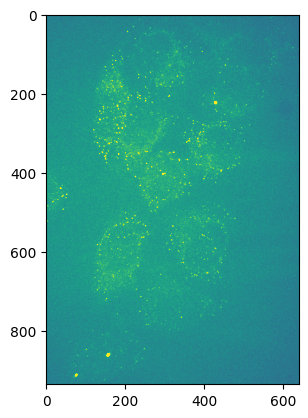

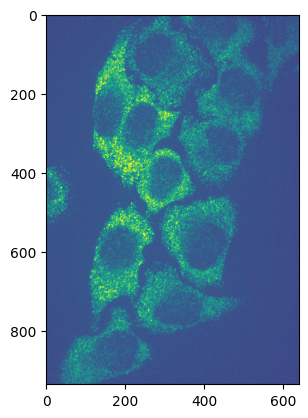

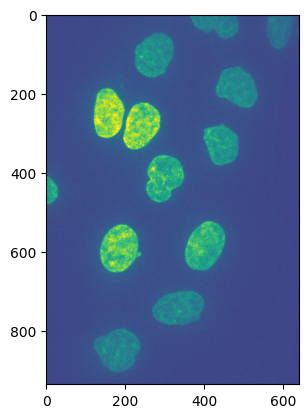

In [12]:
# load in images
d = h5_file['raw_images']
# p, t, c, z, y, x
images = da.from_array(d, (1,1,-1,-1,-1,-1))

# display each of the channels
def display_channel(channel):
    plt.imshow(np.max(images[0,0,channel,:,:,:], axis=0))
    # increase the contrast of the image automatically
    plt.clim(0, np.percentile(images[0,0,channel,:,:,:].flatten(), 99.99))
    plt.show()

for i in range(images.shape[2]):
    display_channel(i)

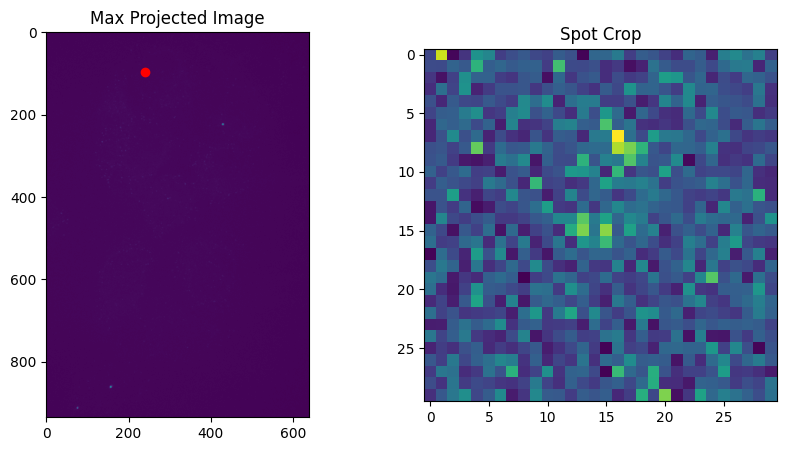

In [5]:
# build gui to classify spots
def classify_spots(image, spot_df, fish_channel):
    # Go to the first position (index 0), first time point (index 1), and the fish channel (index 2)
    img = image[0, 0, fish_channel, :, :, :]
    
    # Max project on the z axis (index 4)
    max_proj_img = np.max(img, axis=0)
    
    # Create a column of NaN in the spot df called good_spots
    spot_df['good_spots'] = np.nan
    
    # Initialize the position index
    pos_index = 0

    current_spots = spot_df[spot_df['fov'] == 0]
    
    if current_spots.empty:
        print(f"No spots found for position {0}")
        return
    
    def update_display(idx):
        clear_output(wait=True)
        
        # Filter spots for the current position
        current_spots = spot_df[spot_df['fov'] == pos_index]
        spot = current_spots.iloc[idx]
        if current_spots.empty:
            print(f"No spots found for position {pos_index}")
            return
        
        # Display each spot
        y, x = int(spot['y_px']), int(spot['x_px'])
        crop = max_proj_img[y-15:y+15, x-15:x+15]
        
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(max_proj_img)
        ax[0].scatter([x], [y], c='r')
        ax[0].set_title('Max Projected Image')
        
        ax[1].imshow(crop)
        ax[1].set_title('Spot Crop')
        
        plt.show()
        
        def mark_good(b):
            nonlocal idx
            spot_df.at[idx, 'good_spots'] = 1
            idx += 1
            update_display(idx)
        
        def mark_bad(b):
            nonlocal idx
            spot_df.at[idx, 'good_spots'] = 0
            idx += 1
            update_display(idx)
        
        def next_image(b):
            nonlocal pos_index
            nonlocal idx
            nonlocal img
            nonlocal max_proj_img
            pos_index += 1
            idx = 0
            img = image[pos_index, 0, fish_channel, :, :, :]
            # Max project on the z axis (index 4)
            max_proj_img = np.max(img, axis=0)
            update_display(idx)
        
        def finish(b):
            print("Finished classifying spots")
            return

        
        finish_button = widgets.Button(description="Finish")
        finish_button.on_click(finish)
        
        good_button = widgets.Button(description="Good Spot")
        good_button.on_click(mark_good)
        
        bad_button = widgets.Button(description="Bad Spot")
        bad_button.on_click(mark_bad)
        
        next_button = widgets.Button(description="Next Image")
        next_button.on_click(next_image)
        
        display(widgets.HBox([good_button, bad_button, next_button, finish_button]))


    break_loop = False
    idx = 0
    spot = current_spots.iloc[idx]
    update_display(idx)

# Example usage
classify_spots(images, spots, fish_channel=0)




In [6]:
spots

,z_px,y_px,x_px,cluster_index,timepoint,fov,FISH_Channel,good_spots
0,4,95,241,-1,0,0,0,NaN
1,4,155,346,-1,0,0,0,NaN
2,4,162,297,-1,0,0,0,NaN
3,4,274,388,-1,0,0,0,NaN
4,4,279,167,-1,0,0,0,NaN
...,...,...,...,...,...,...,...,...
1641,18,470,275,-1,0,0,0,NaN
1642,19,593,181,-1,0,0,0,NaN
1643,18,592,181,-1,0,0,0,NaN
1644,19,900,312,-1,0,0,0,NaN


In [7]:
# build binary classifier to classify spots as good or bad
input_width = 36

model = nn.Sequential(
    nn.Conv2d(1, 1, kernel_size=3, padding=1),
    nn.Sigmoid(),
    nn.Conv2d(1, 1, kernel_size=3, padding=1),
    nn.Sigmoid(),
    nn.Flatten(),
    nn.Linear(input_width**2, 1),
    nn.Sigmoid()
)

In [ ]:
# train classifier
def extract_images(image, xyz, width):
    z, y, x = xyz
    return np.max(image[:, y-width//2:y+width//2, x-width//2:x+width//2], axis=0)

for i, row in spots.iterrows():
    if row['good_spots'] == 1 or row['good_spots'] == 0:
        # Extract the image
        img = extract_images(images[row['fov'], row['timepoint'], row['FISH_Channel']:, :, :], (row['z_px'], row['y_px'], row['x_px']), input_width)
        
        # Convert to tensor
        img_tensor = torch.tensor(img).float()
        
        # Predict
        prediction = model(img_tensor)
        
        # Update the spot df
        spots.at[i, 'good_spots'] = prediction.item()



In [ ]:
# save classifier



In [ ]:
# save data location of training data
